In [13]:
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import numpy.ma as ma
import sys
sys.path.insert(1, '/Users/nityaravi/Documents/GitHub/RotationCurves/ellipticals/')

from IO_data import extract_data, extract_Pipe3d_data
from elliptical_plottingFunctions import plot_sigma_map

In [21]:
matplotlib.rcParams['figure.dpi'] = 100
matplotlib.rcParams['savefig.dpi'] = 300

In [30]:
data_dir = '/Users/nityaravi/Documents/Research/RotationCurves/data/manga/'
image_dir = '/Users/nityaravi/Documents/Research/RotationCurves/data/manga/Ellipticals_Images/paper_plots/'

In [31]:
test_gal = '8319-1902'

In [32]:
maps = extract_data(data_dir + 'DR17/', test_gal, ['star_sigma'])
pipe3d_maps = extract_Pipe3d_data(data_dir + 'Pipe3D/', test_gal, ['sMass'])

In [33]:
star_sigma = maps['star_sigma']
star_sigma_ivar = maps['star_sigma_ivar']
star_sigma_mask = maps['star_sigma_mask']
star_sigma_corr = maps['star_sigma_corr']

sMass_density = pipe3d_maps['sMass_density']
sMass_density_err = pipe3d_maps['sMass_density_err']

sn10_mask = np.logical_or(star_sigma * 
                               np.sqrt(star_sigma_ivar) < 10, 
                               star_sigma_mask)

default_star_sigma = ma.array(star_sigma, mask=star_sigma_mask)

mstar_sigma = ma.array(star_sigma, mask=sn10_mask)
mstar_sigma_ivar = ma.array(star_sigma_ivar, mask=sn10_mask)
mstar_sigma_corr = ma.array(star_sigma_corr, mask=sn10_mask)

mstar_sigma_corrected = np.sqrt(mstar_sigma**2 - mstar_sigma_corr**2)

msMass_density = ma.array(sMass_density, mask=sn10_mask)
msMass_density_err = ma.array(sMass_density_err, mask=sn10_mask)

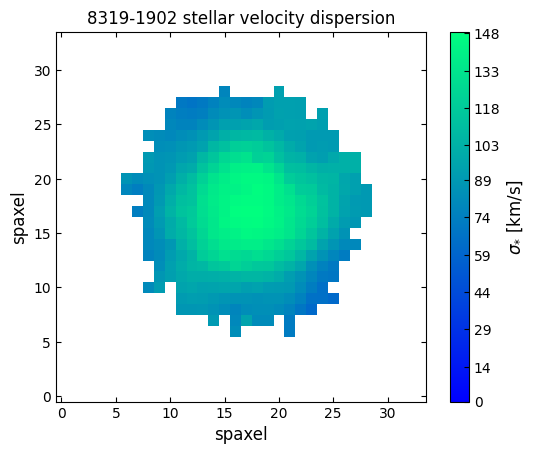

In [38]:
fig, ax = plt.subplots()

vmax = ma.max(mstar_sigma)
cbar_ticks = np.linspace( 0, vmax, 11, dtype='int')

ax.set_title(test_gal + ' stellar velocity dispersion', fontsize=12)
############################################################################


############################################################################
# Create plot
#---------------------------------------------------------------------------
vel_im = ax.imshow( mstar_sigma, 
                    cmap='winter', # 4h 
                    origin='lower', 
                    vmin=0, 
                    vmax=vmax)

cbar = plt.colorbar( vel_im, ax=ax, ticks=cbar_ticks)
cbar.ax.tick_params( direction='in', labelsize=10)
cbar.set_label(r'$\sigma_{*}$ [km/s]', fontsize=12) 

ax.tick_params( axis='both', direction='in', labelsize=10)
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.set_xlabel('spaxel', fontsize=12)
ax.set_ylabel('spaxel', fontsize=12)

plt.savefig( image_dir + test_gal + '_star_sigma.png', 
             format='png', 
             bbox_inches = 'tight', 
             pad_inches = 0
             )

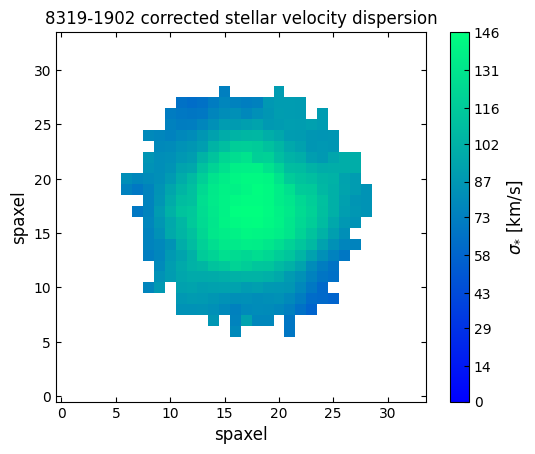

In [40]:
fig, ax = plt.subplots()

vmax = ma.max(mstar_sigma_corrected)
cbar_ticks = np.linspace( 0, vmax, 11, dtype='int')

ax.set_title(test_gal + ' corrected stellar velocity dispersion', fontsize=12)
############################################################################


############################################################################
# Create plot
#---------------------------------------------------------------------------
vel_im = ax.imshow( mstar_sigma_corrected, 
                    cmap='winter', # 4h 
                    origin='lower', 
                    vmin=0, 
                    vmax=vmax)

cbar = plt.colorbar( vel_im, ax=ax, ticks=cbar_ticks)
cbar.ax.tick_params( direction='in', labelsize=10)
cbar.set_label(r'$\sigma_{*}$ [km/s]', fontsize=12) 

ax.tick_params( axis='both', direction='in', labelsize=10)
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.set_xlabel('spaxel', fontsize=12)
ax.set_ylabel('spaxel', fontsize=12)

plt.savefig( image_dir + test_gal + '_star_sigma_corrected.png', 
             format='png', 
             bbox_inches = 'tight', 
             pad_inches = 0
             )

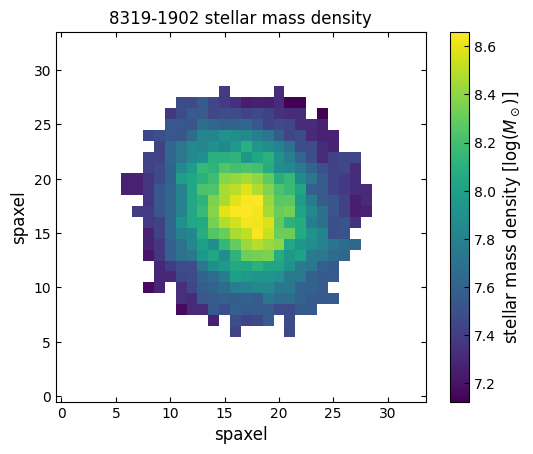

In [42]:
fig, ax = plt.subplots()

vmax = ma.max(msMass_density)
#cbar_ticks = np.linspace( 0, vmax, 11, dtype='int')

ax.set_title(test_gal + ' stellar mass density', fontsize=12)
############################################################################


############################################################################
# Create plot
#---------------------------------------------------------------------------
vel_im = ax.imshow( msMass_density, 
                    cmap='viridis', 
                    origin='lower', 
                    #vmin=0, 
                    #vmax=vmax
                  )

cbar = plt.colorbar( vel_im, ax=ax)
cbar.ax.tick_params( direction='in', labelsize=10)
cbar.set_label(r'stellar mass density $[\log(M_\odot)]$', fontsize=12) 

ax.tick_params( axis='both', direction='in', labelsize=10)
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.set_xlabel('spaxel', fontsize=12)
ax.set_ylabel('spaxel', fontsize=12)

plt.savefig( image_dir + test_gal + '_sMass_density.png', 
             format='png', 
             bbox_inches = 'tight', 
             pad_inches = 0
             )